# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Botron, Christan Jake
- _Student No._: 2024-10168
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Prob2.1](./figures/prob2_1.png)
*Figure 1. Effects of hardware floating-point precision on catastrophic cancellation for $f(x) = \sqrt{x^2+x} - x$. Notice where each line breaks off from the "good equation" and goes to $y=0$. That is where the catastrophic cancellation starts.* 


![Prob2.2](./figures/prob2_2.png)
*Figure 2. Effects of hardware floating-point precision on catastrophic cancellation for $\frac{e^x - 1}{x}$. Notice where each line breaks off from the "good equation" and goes to $y=0$. That is where the catastrophic cancellation starts.*

As we can see from Figures 1 and 2, the onset of catastrophic cancellation is directly dictated by the hardware's machine epsilon, which is determined by the different hardware floating-point precisions. In both evaluated functions, lower precisions collapse much earlier because they lack the significant digits required to resolve extreme magnitude differences. For the first equation (Figure 1), 16-bit precision fails completely around $x = 10^3$, 32-bit around $10^7$, 64-bit around $10^{16}$, and 128-bit sustains accuracy until roughly around $10^{19}$. Similarly, when evaluating the second equation (Figure 2) near zero, 16-bit loses all precision around $x = 10^{-3}$, whereas 32-bit, 64-bit, and 128-bit collapse near $10^{-7}$, $10^{-16}$, and $10^{-19}$, respectively. While upgrading to a higher precision drastically delays the catastrophic cancellation point by expanding the range of representable significant digits, it only postpones the catastrophic cancellation and does not fix it.

### Report discussion

In Problem 1, the "bad" formula evaluates the standard quadratic equation $x_+ = \frac{-b + \sqrt{b^2 - 4ac}}{2a}$. When $b$ is extremely large (e.g., $10^8$), this evaluates a subtraction of nearly identical values, causing a catastrophic loss of significant digits, and thus a catastrophic cancellation. The "good" formula prevents this by first computing the mathematically stable root, $x_-$. Because the numerator $-b - \sqrt{b^2 - 4ac}$ contains only negative terms, it safely evaluates as an addition of magnitudes. This stable root is then utilized to solve for the second root using the analytical product $x_+x_- = c/a$. This same analytical trick resolves the first part of Problem 2, where extreme magnitudes of $x$ yield catastrophic cancellation that forces the output to $0.0$ rather than the expected limit of $0.5$. By treating the evaluation as finding the roots of a system, the product yields $y_+y_- = -x$. Computing the stable root $y_-$ first allows the unstable root to be evaluated purely through division (i.e., $y_+ = \frac{-x}{y_-}$), bypassing the catastrophic cancellation. The second part of Problem 2 demonstrates a similar yet distinct (same concept but for smaller x) failure for values approaching zero ($x = 10^{-20}$). Because $e^x \approx 1 + x$ for extremely small values, the addition in the numerator evaluates to $0.0$ due to round-off error when it is smaller than the 64-bit machine epsilon. The machine rounds $e^x$ exactly to $1.0$, incorrectly forcing the numerator $e^x - 1$ to $0.0$ instead of the expected limit of $1.0$. This was remedied by utilizing np.expm1(x), which switches to a Maclaurin series expansion (or Taylor series expansion around $x=0$) to preserve the crucial fractional bits.

### Other comments

I have no other comments.


## Section 2 (Problems and Code)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
from decimal import Decimal
from fractions import Fraction

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
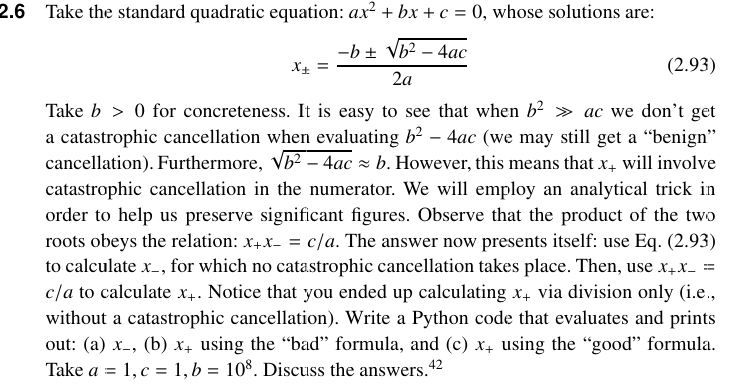

In [11]:
def quadratic_eq(a,b,c): 
    x_mn = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)                              #stable root
    x_pl_bad_float32 = (-b + np.float32(np.sqrt(b**2 - 4*a*c))) / (2*a)
    x_pl_bad_float64 = (-b + np.float64(np.sqrt(b**2 - 4*a*c))) / (2*a)
    x_pl_bad_float128 = (-b + np.float128(np.sqrt(b**2 - 4*a*c))) / (2*a)
    x_pl_good = c / (a*x_mn)
    return x_mn, x_pl_bad_float32, x_pl_bad_float64, x_pl_bad_float128, x_pl_good

In [12]:
print("x- =", quadratic_eq(1,1e9,1)[0])
print("x+ (bad; 32 bit) =", quadratic_eq(1,1e9,1)[1])
print("x+ (bad; 64 bit) =", quadratic_eq(1,1e9,1)[2])
print("x+ (bad; 128 bit) =", quadratic_eq(1,1e9,1)[3])
print("x+ (good) =", quadratic_eq(1,1e9,1)[4])

x- = -1000000000.0
x+ (bad; 32 bit) = 0.0
x+ (bad; 64 bit) = 0.0
x+ (bad; 128 bit) = 0.0
x+ (good) = -1e-09


#### Problem 1 code summary

Using the standard quadratic formula to calculate $x_+$ fails due to catastrophic cancellation when $b$ is extremely large. This is because the function incorrectly evaluates to zero as it subtracts nearly identical floating-point numbers. To prevent this precision loss, I first computed the more stable root that is $x_-$. I call it a stable root as it safely adds two negative magnitudes, and thus does not cancel out. By utilizing the analytical product of the roots to rearrange the equation to $x_+ = \frac{c}{a \cdot x_-}$, the problematic root, $x_+$, is precisely calculated.


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [13]:
#This function shows the rewritten method to avoid the catastrophic cancellation
def f_1(x):
    y_mn = -np.sqrt(x**2 + x) - x
    y_pl_bad = np.sqrt(x**2 + x) - x
    y_pl_good = -x/y_mn                        #y+*y- = x^2 - (x^2 + x) = -x ==> y+ = - x/(y-)
    return y_mn, y_pl_bad, y_pl_good

In [14]:
print("(y-, y+ (bad), y+ (good))") 
print(f_1(1e15))
print(f_1(1e16))
print(f_1(1e17))
print(f_1(1e18))
#note: these are all in 64-bit

(y-, y+ (bad), y+ (good))
(-2000000000000000.5, 0.5, 0.4999999999999999)
(-2e+16, 2.0, 0.5)
(-2e+17, 0.0, 0.5)
(-2e+18, 0.0, 0.5)


/opt/conda/lib/python3.11/site-packages/numpy/core/function_base.py:285: RuntimeWarning: overflow encountered in cast
  return _nx.power(base, y).astype(dtype, copy=False)
/tmp/ipykernel_2254564/2650865156.py:4: RuntimeWarning: overflow encountered in square
  return np.sqrt(x**2 + x) - x
/tmp/ipykernel_2254564/2650865156.py:4: RuntimeWarning: invalid value encountered in subtract
  return np.sqrt(x**2 + x) - x


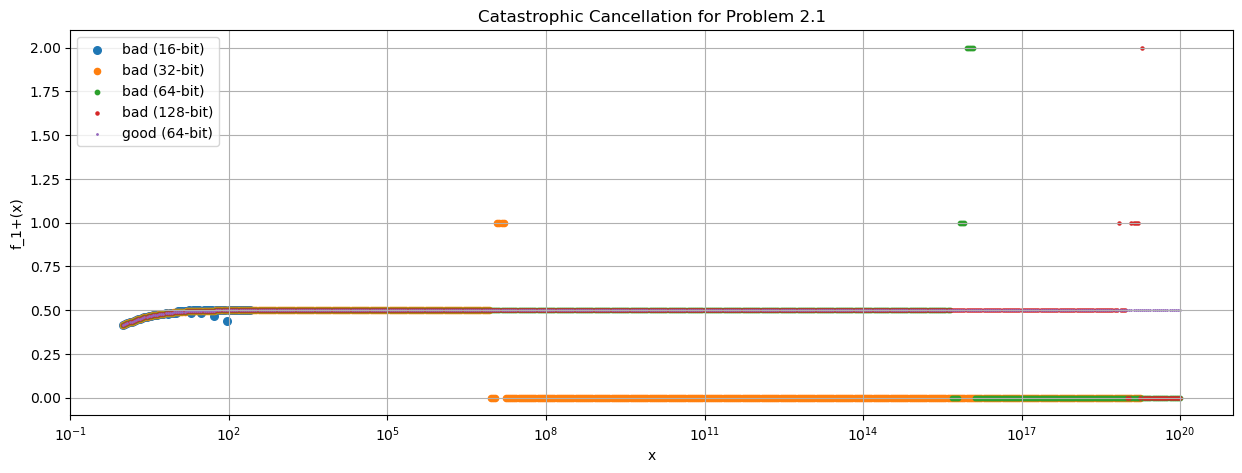

In [15]:
#graph

def f_1_bad(x):
    return np.sqrt(x**2 + x) - x
def f_1_good(x):
    return -x / (-np.sqrt(x**2 + x) - x)                   #-x/(y-); refer to above function

bitnum = [np.float16, np.float32, np.float64, np.float128]
label = ["bad (16-bit)", "bad (32-bit)", "bad (64-bit)", "bad (128-bit)"]
size = [30,20,10,5]

plt.figure(figsize=(15, 5))

for dtype, label, size in zip(bitnum,label,size):                     #plot of bad functions
    x = np.logspace(0, 20, 501, dtype=dtype)
    y = f_1_bad(x)
    plt.scatter(x, y, s=size, label=label)

x_1_good = np.logspace(0, 20, 501, dtype=np.float64)
y_1_good = f_1_good(x)
plt.scatter(x_1_good, y_1_good, s=1, label="good (64-bit)")             #plot of good function (64-bit)

plt.xscale('log')
plt.xlabel('x')
plt.ylabel('f_1+(x)')

plt.title('Catastrophic Cancellation for Problem 2.1')
plt.legend()
plt.grid(True, which="both")
plt.savefig('figures/prob2_1.png', bbox_inches='tight', dpi=300)
plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [16]:
def f_2(x):
    y_bad = (np.exp(x) - 1) / x
    y_good = np.expm1(x)/x
    return y_bad, y_good

In [17]:
f_2(1e-16)

(0.0, 1.0)

/tmp/ipykernel_2254564/1807113654.py:4: RuntimeWarning: invalid value encountered in divide
  return (np.exp(x) - 1) / x


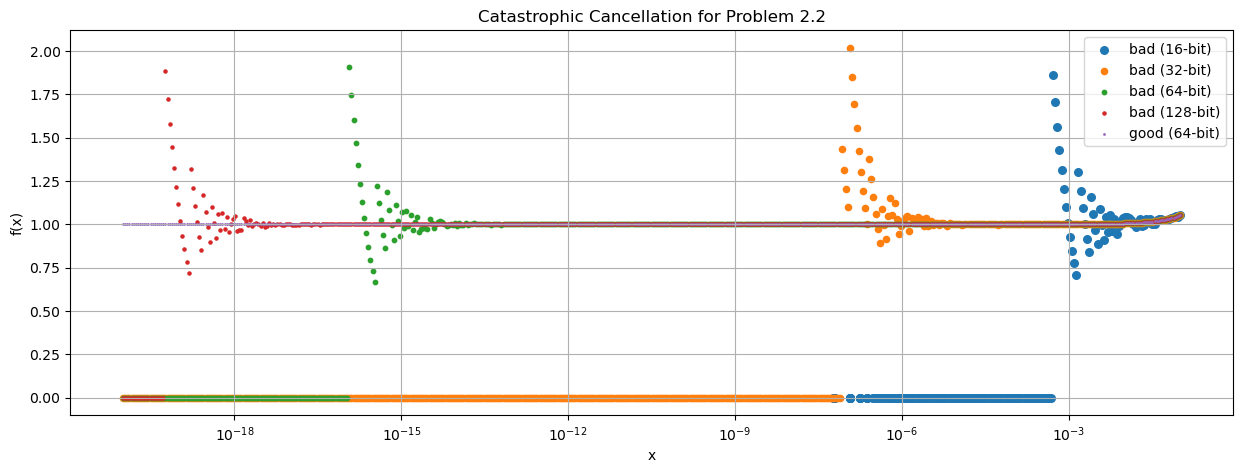

In [18]:
#graph

def f_2_bad(x):
    return (np.exp(x) - 1) / x
def f_2_good(x):
    return np.expm1(x)/x              

bitnum = [np.float16, np.float32, np.float64, np.float128]
label = ["bad (16-bit)", "bad (32-bit)", "bad (64-bit)", "bad (128-bit)"]
size = [30,20,10,5]

plt.figure(figsize=(15, 5))

for dtype, label, size in zip(bitnum,label,size):                     #plot of bad functions
    x = np.logspace(-20, -1, 501, dtype=dtype)
    y = f_2_bad(x)
    plt.scatter(x, y, s=size, label=label)

x_2_good = np.logspace(-20, -1, 501, dtype=np.float64)
y_2_good = f_2_good(x)
plt.scatter(x_2_good, y_2_good, s=1, label="good (64-bit)")             #plot of good function (64-bit)

plt.xscale('log')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Catastrophic Cancellation for Problem 2.2')
plt.legend()
plt.grid()
plt.savefig('figures/prob2_2.png', bbox_inches='tight', dpi=300)
plt.show()

#### Problem 2 code summary

1. For part 1 of problem 2, the workaround is similar to problem 1, as it also features a square root (so there should be 2 roots, i.e., $y_-$ and $y_+$). I found that multiplying the roots yields $y_-y_+ = -x$, so what I did was first find the more stable root, $y_-$ using the actual equation, and then use the earlier expression to find $y_+, i.e., y_+ = -x/(y_-)$. This checks out with the plot (in 64-bit), as seen in the figure where the $y_+$ value for $x=1e16=10^{16}$ is $2.0$. Furthermore, from the plot, we can see that the fewer the bits, the faster they "disintegrate" or experience the cancellation catastrophe.

2. The idea in part 2 is essentially the same. I used np.expm1(x) to have a more accurate representation of $e^x - 1$. The reason why we cannot use the usual (np.exp(x)-1)/x equation is that for really small x values, $e^x = 1+x$. The machine epsilon for 64-bit is roughly $2.22\times10^{-16}$, which explains why the cancellation catastrophe for this equation occurs at around $10^{16}$ (i.e., $e^x = 1+x \approx 1 => e^x - 1 = 0$), as $10^{16}$ is less than the machine epsilon for 64-bit. The NumPy function np.expm1(x) fixes this as it essentially rewrites the equation into a Maclaurin series expansion, which outputs a more precise value rather than rounding it to $1.0$. This result may also be seen in the plot generated for part 2. Similar to part 1, the catastrophic cancellation occurs much earlier for fewer bits. The seemingly random dots prior to the cancellation catastrophe look random because the computer is forced to round the numerator into discrete steps (1+1$\epsilon$, 1+2$\epsilon$, ...) for small x while the denominator shrinks smoothly, creating a jagged pattern sampled at irregular intervals.


---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))